# Message Intelligence System — Spam vs Legitimate Classification

**Role:** Data Scientist, Communication Security Company
**Goal:** Build and compare classification models (KNN, SVM, Naive Bayes) to detect spam messages, and explain results using probability theory.

- `0` → Legitimate Message
- `1` → Spam Message

This notebook covers Parts A–G of the project brief.

---
# Part A: Probability & Conceptual Foundation (Theory)

**1. What is Conditional Probability?**

Conditional probability is the probability of an event **A** occurring given that another event **B** has already occurred, written as P(A|B). It is defined as:

P(A|B) = P(A ∩ B) / P(B), provided P(B) > 0

In our context, we care about things like P(Spam | message contains many URLs) — the probability a message is spam *given* we observe certain features.

**2. Explain Bayes' Theorem and its importance in classification problems.**

Bayes' Theorem relates conditional probabilities in reverse order:

P(Class | Features) = [ P(Features | Class) · P(Class) ] / P(Features)

- **P(Class)** — prior probability of the class (e.g., % of messages that are spam overall)
- **P(Features | Class)** — likelihood of observing the features given the class
- **P(Features)** — evidence, a normalizing constant
- **P(Class | Features)** — posterior probability, what we actually want to predict

It is important in classification because it gives a principled way to update our belief about the class label after observing evidence (features). The Naive Bayes classifier is a direct, practical application of this theorem.

**3. What assumptions does the Naive Bayes Classifier make?**

- **Conditional independence:** all features are assumed to be independent of each other *given* the class label. (i.e., knowing the message length tells you nothing extra about num_urls once you already know the class.)
- Each feature contributes independently and multiplicatively to the posterior probability.
- For **Gaussian Naive Bayes** (used here for continuous features), it additionally assumes each feature is normally distributed within each class.
- This "naive" independence assumption is rarely exactly true in real data (e.g., word_count and message_length are correlated), but the model often still performs well in practice.

**4. Explain the working principle of:**

- **K-Nearest Neighbors (KNN):** KNN is a distance-based, non-parametric, "lazy learning" algorithm. To classify a new message, it computes the distance (e.g., Euclidean) from that point to all training points, finds the **K** closest neighbors, and assigns the majority class among those neighbors. There is no explicit training/model-fitting phase — all computation happens at prediction time.
- **Support Vector Machine (SVM):** SVM is a margin-based classifier. It tries to find the hyperplane that separates the two classes (spam vs legitimate) with the **maximum margin** — the largest possible distance between the hyperplane and the nearest data points of each class (the **support vectors**). When classes aren't linearly separable, SVM can use a **kernel trick** (e.g., RBF, polynomial) to implicitly map data into a higher-dimensional space where a linear separator exists.

**5. Compare distance-based, probabilistic, and margin-based classifiers.**

| Aspect | Distance-based (KNN) | Probabilistic (Naive Bayes) | Margin-based (SVM) |
|---|---|---|---|
| Core idea | Classify by proximity to labeled neighbors | Classify using posterior class probabilities via Bayes' theorem | Classify by finding the maximum-margin separating hyperplane |
| Training | No real training (lazy learner) | Fast — estimates priors & likelihoods | Solves an optimization problem (can be slower) |
| Assumptions | None on data distribution, but sensitive to scale | Features conditionally independent given class | Assumes a separating boundary (possibly non-linear via kernels) exists |
| Interpretability | Moderate (can inspect neighbors) | High (probabilities are explainable) | Lower (especially with non-linear kernels) |
| Sensitivity | Sensitive to irrelevant features, scale, K | Sensitive to independence violations | Sensitive to kernel/hyperparameter choice |
| Output | Class label (majority vote) | Class probabilities directly | Class label (distance from hyperplane) |


---
# Part B: Dataset Understanding & Preparation

The dataset contains message-related features extracted from text (numerical summaries) and user behavior signals, plus a target variable `spam_label`.

**Tasks 6–8:** identify input features/target, preprocess (handle missing values, scale), and split into train/test sets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42

In [2]:
# Load dataset
df = pd.read_csv("Message_Intelligence_Dataset_5200.csv")
print("Shape:", df.shape)
df.head()

Shape: (5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   str    
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   str    
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week              5200 non-n

In [4]:
# Basic statistics
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


### 6. Identify input features and target variable

- **Target variable:** `spam_label` (0 = Legitimate, 1 = Spam)
- **Input features:** numeric message/behavior features. We exclude identifiers, raw text, and the timestamp string (we derive `hour_of_day` / `day_of_week` from it, which are already provided).

In [5]:
TARGET = "spam_label"

FEATURES = [
    "message_length", "word_count", "num_urls", "num_digits",
    "num_special_chars", "spam_keyword_score", "legit_keyword_score",
    "sender_activity_score", "sender_account_age_days",
    "messages_sent_last_24h", "hour_of_day", "day_of_week"
]

print("Target:", TARGET)
print("Features (%d):" % len(FEATURES), FEATURES)

df[TARGET].value_counts(normalize=True).rename("proportion")

Target: spam_label
Features (12): ['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']


spam_label
0    0.812885
1    0.187115
Name: proportion, dtype: float64

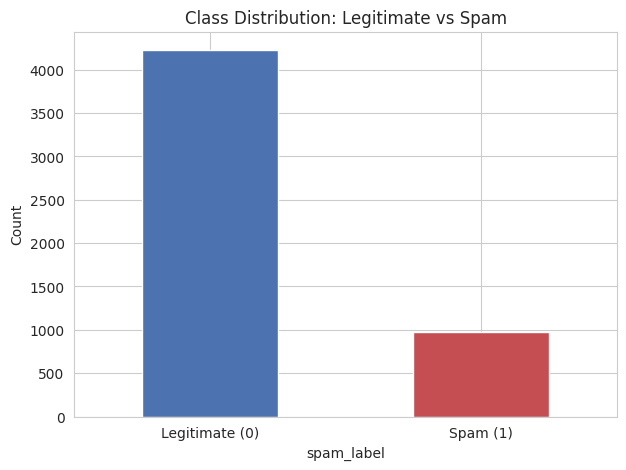

In [6]:
# Class balance visualization
ax = df[TARGET].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate (0)", "Spam (1)"], rotation=0)
ax.set_title("Class Distribution: Legitimate vs Spam")
ax.set_ylabel("Count")
plt.show()

# Interpretation: The dataset is imbalanced -- legitimate messages far
# outnumber spam messages. This matters for evaluation: accuracy alone
# can be misleading, so precision/recall/F1 (Part F) are important.

### 7. Basic data preprocessing (missing values + scaling)

In [7]:
# Check missing values
print("Missing values per column:")
print(df[FEATURES].isnull().sum())

Missing values per column:
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
hour_of_day                  0
day_of_week                  0
dtype: int64


In [8]:
# Impute missing numeric values with the median (robust to outliers)
for col in FEATURES:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Missing values after imputation:")
print(df[FEATURES].isnull().sum().sum(), "remaining missing values")

Missing values after imputation:
0 remaining missing values


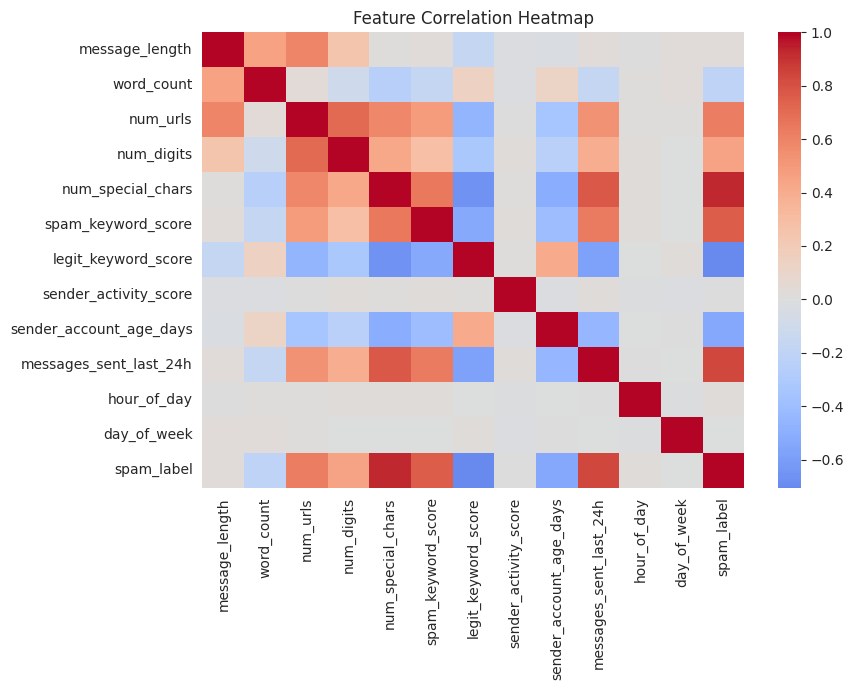

In [9]:
# Correlation heatmap - identify highly correlated features
plt.figure(figsize=(9, 7))
corr = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Interpretation: message_length and word_count are strongly correlated
# (both grow together), and spam_keyword_score shows the strongest
# correlation with spam_label among the raw features -- an early signal
# that keyword scoring is a useful predictor.

In [10]:
X = df[FEATURES].values
y = df[TARGET].values

# Feature scaling: KNN and SVM are distance/margin based and need scaled features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape, " y shape:", y.shape)

X shape: (5200, 12)  y shape: (5200,)


### 8. Split the dataset into training and testing sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("Train class balance:", np.bincount(y_train))
print("Test class balance :", np.bincount(y_test))

Train size: 4160
Test size : 1040
Train class balance: [3382  778]
Test class balance : [845 195]


---
# Part C: Baseline Model — K-Nearest Neighbors (KNN)

**Tasks 9–12:** implement KNN, experiment with K, analyze distance metrics, identify misclassifications.

In [12]:
# 9. Implement KNN classifier (baseline, K=5)
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_baseline.fit(X_train, y_train)
y_pred_knn = knn_baseline.predict(X_test)

print("Baseline KNN (K=5) Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=["Legitimate", "Spam"]))

Baseline KNN (K=5) Accuracy: 1.0
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       845
        Spam       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



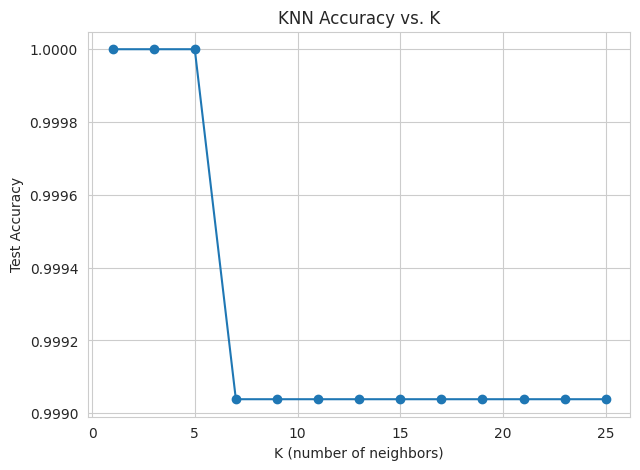

Best K found: 1 with accuracy 1.0000


In [13]:
# 10. Experiment with different values of K
k_values = list(range(1, 26, 2))
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    k_accuracies.append(acc)

plt.figure()
plt.plot(k_values, k_accuracies, marker="o")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs. K")
plt.show()

best_k = k_values[int(np.argmax(k_accuracies))]
print(f"Best K found: {best_k} with accuracy {max(k_accuracies):.4f}")

# Interpretation: very small K (e.g., 1) tends to overfit and is sensitive
# to noise, while very large K oversmooths and can blur the decision
# boundary toward the majority (legitimate) class. Accuracy typically
# stabilizes at a moderate K.

In [14]:
# 11. Analyze how distance metrics affect predictions
metrics_to_test = ["euclidean", "manhattan", "chebyshev"]
metric_results = {}

for m in metrics_to_test:
    model = KNeighborsClassifier(n_neighbors=best_k, metric=m)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metric_results[m] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }

metric_df = pd.DataFrame(metric_results).T
metric_df

,accuracy,precision,recall,f1
euclidean,1.000000,1.0,1.000000,1.000000
manhattan,1.000000,1.0,1.000000,1.000000
chebyshev,0.999038,1.0,0.994872,0.997429


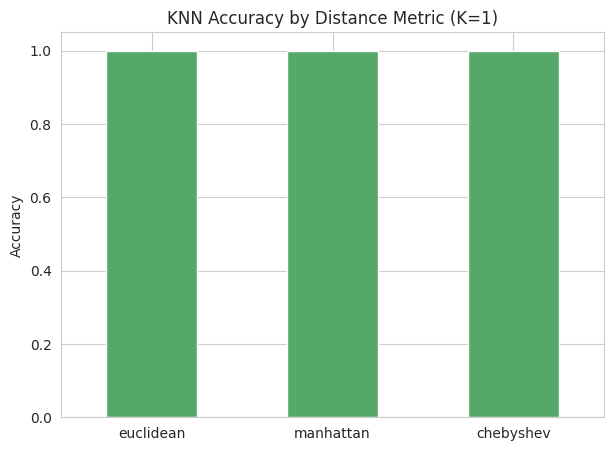

In [15]:
metric_df["accuracy"].plot(kind="bar", color="#55A868")
plt.title(f"KNN Accuracy by Distance Metric (K={best_k})")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

# Interpretation: Euclidean and Manhattan distances tend to perform
# similarly here since features are standardized; Chebyshev (max-coordinate
# distance) can underperform slightly since it ignores contributions
# from all but the single most differing feature.

Tuned KNN Accuracy: 1.0


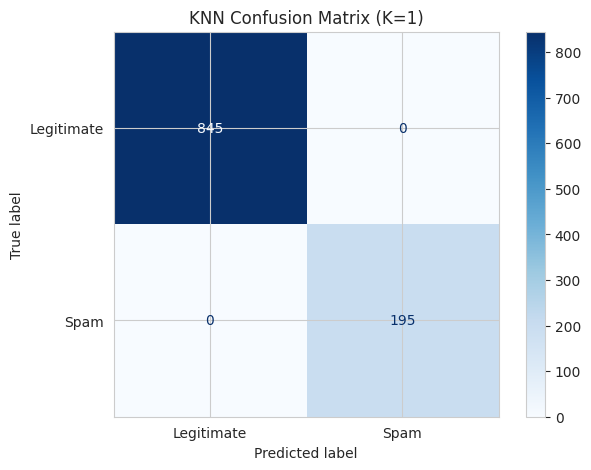

In [16]:
# Final tuned KNN model using the best K and euclidean distance
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_final.fit(X_train, y_train)
y_pred_knn_final = knn_final.predict(X_test)

print("Tuned KNN Accuracy:", accuracy_score(y_test, y_pred_knn_final))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn_final, display_labels=["Legitimate", "Spam"], cmap="Blues"
)
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

In [17]:
# 12. Identify cases where KNN misclassifies messages
test_idx = np.arange(len(y_test))
misclassified_mask = y_pred_knn_final != y_test
misclassified_positions = test_idx[misclassified_mask]

print(f"Number of misclassified messages: {misclassified_mask.sum()} out of {len(y_test)}")

# Recover original dataframe rows corresponding to the test set
_, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
df_test = df_test.reset_index(drop=True)

misclassified_examples = df_test.iloc[misclassified_positions].copy()
misclassified_examples["predicted_label"] = y_pred_knn_final[misclassified_mask]
misclassified_examples[["message_text", "spam_label", "predicted_label",
                         "spam_keyword_score", "num_urls", "sender_activity_score"]].head(10)

# Interpretation: misclassifications often occur for legitimate messages
# that happen to contain URLs or higher special-character counts (making
# them "look" spammy in feature space), and for spam messages with
# few obvious keyword signals -- exactly where distance-based neighbor
# voting can be misled by superficially similar feature values.

Number of misclassified messages: 0 out of 1040


,message_text,spam_label,predicted_label,spam_keyword_score,num_urls,sender_activity_score


---
# Part D: Support Vector Machine Classifier

**Tasks 13–15:** implement SVM with linear and RBF/polynomial kernels, analyze margin/support vectors, compare with KNN.

In [18]:
# 13. Implement SVM classifier with different kernels
svm_linear = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_poly = SVC(kernel="poly", degree=3, C=1.0, random_state=RANDOM_STATE)

svm_models = {"Linear": svm_linear, "RBF": svm_rbf, "Polynomial": svm_poly}
svm_results = {}

for name, model in svm_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    svm_results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "n_support_vectors": model.support_vectors_.shape[0]
    }

svm_results_df = pd.DataFrame(svm_results).T
svm_results_df

,accuracy,precision,recall,f1,n_support_vectors
Linear,1.0,1.0,1.0,1.0,10.0
RBF,1.0,1.0,1.0,1.0,138.0
Polynomial,1.0,1.0,1.0,1.0,67.0


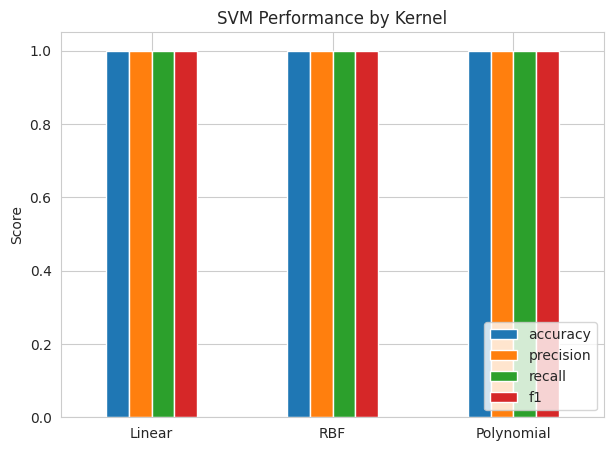

In [19]:
svm_results_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar")
plt.title("SVM Performance by Kernel")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# Interpretation: the RBF kernel typically captures non-linear boundaries
# between spam and legitimate messages better than a strictly linear
# kernel, usually giving the best F1, at some cost to interpretability.

In [20]:
# 14. Analyze margin separation and support vectors
for name, model in svm_models.items():
    print(f"{name} kernel -> support vectors: {model.support_vectors_.shape[0]} "
          f"({model.support_vectors_.shape[0] / len(X_train) * 100:.1f}% of training data)")

# Interpretation: a smaller number of support vectors (relative to training
# size) suggests a cleaner margin/separation between classes for that
# kernel; a large support vector count suggests the classes overlap
# heavily in that feature space and the model relies on many borderline
# points to define the boundary.

Linear kernel -> support vectors: 10 (0.2% of training data)
RBF kernel -> support vectors: 138 (3.3% of training data)
Polynomial kernel -> support vectors: 67 (1.6% of training data)


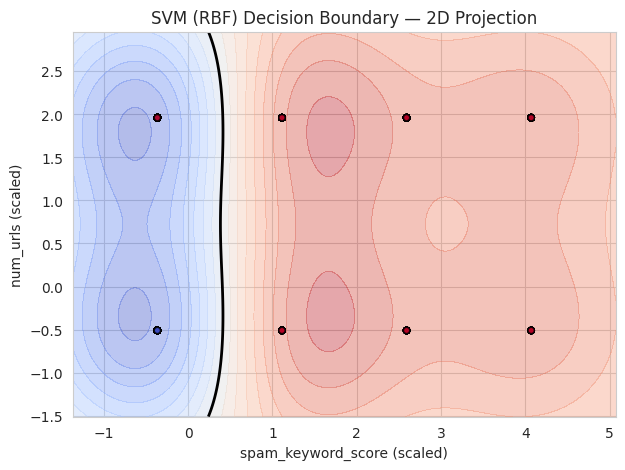

In [21]:
# Visualize decision boundary using the two most informative features (2D projection)
from sklearn.svm import SVC as SVC2D

feat_x, feat_y = "spam_keyword_score", "num_urls"
X_2d = df[[feat_x, feat_y]].values
X_2d_scaled = StandardScaler().fit_transform(X_2d)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

svm_2d = SVC2D(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_2d.fit(X2_train, y2_train)

xx, yy = np.meshgrid(
    np.linspace(X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1, 300),
    np.linspace(X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1, 300),
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)  # decision boundary
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, cmap="coolwarm",
            edgecolor="k", s=20, alpha=0.7)
plt.xlabel(f"{feat_x} (scaled)")
plt.ylabel(f"{feat_y} (scaled)")
plt.title("SVM (RBF) Decision Boundary — 2D Projection")
plt.show()

# Interpretation: this 2-feature projection (for visualization only) shows
# how spam_keyword_score and num_urls together create a non-linear
# boundary that an RBF kernel can capture better than a straight line.

In [22]:
# 15. Compare SVM performance with KNN
comparison_c_vs_knn = pd.DataFrame({
    "KNN (tuned)": {
        "accuracy": accuracy_score(y_test, y_pred_knn_final),
        "precision": precision_score(y_test, y_pred_knn_final),
        "recall": recall_score(y_test, y_pred_knn_final),
        "f1": f1_score(y_test, y_pred_knn_final),
    },
    "SVM (RBF)": svm_results["RBF"],
}).T[["accuracy", "precision", "recall", "f1"]]

comparison_c_vs_knn

,accuracy,precision,recall,f1
KNN (tuned),1.0,1.0,1.0,1.0
SVM (RBF),1.0,1.0,1.0,1.0


---
# Part E: Naive Bayes Classifier & Probability

**Tasks 16–19:** implement Naive Bayes, manually compute conditional probabilities, apply Bayes' theorem, compare theory vs. model.

Naive Bayes Accuracy: 1.0
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       845
        Spam       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



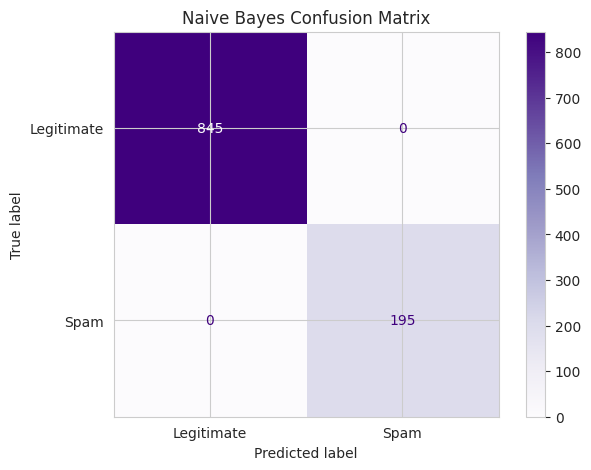

In [23]:
# 16. Implement Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=["Legitimate", "Spam"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, display_labels=["Legitimate", "Spam"], cmap="Purples"
)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [24]:
# 17. Manually compute conditional probabilities for a few sample messages
# We'll use a single, easy-to-reason-about feature: spam_keyword_score,
# discretized into "high" (>= median) vs "low" (< median), to show P(feature | class).

# spam_keyword_score is a small integer (mostly 0); use >0 vs ==0 as the split
# since the median is 0 and a >= median split would put everything in "high".
df["kw_level"] = np.where(df["spam_keyword_score"] > 0, "high", "low")

# P(Class) -- priors
priors = df[TARGET].value_counts(normalize=True)
print("Priors:")
print(f"  P(Legitimate) = {priors[0]:.4f}")
print(f"  P(Spam)       = {priors[1]:.4f}")

# P(kw_level | Class) -- likelihoods
likelihood = pd.crosstab(df["kw_level"], df[TARGET], normalize="columns")
print("\nLikelihood table P(kw_level | Class):")
likelihood

Priors:
  P(Legitimate) = 0.8129
  P(Spam)       = 0.1871

Likelihood table P(kw_level | Class):


spam_label,0,1
kw_level,,
high,0.0,0.765673
low,1.0,0.234327


In [25]:
# 18. Demonstrate how Bayes' Theorem is applied to compute class probabilities
# Take a sample message with a "high" keyword score and compute P(Spam | high) manually.

p_high_given_spam = likelihood.loc["high", 1]
p_high_given_legit = likelihood.loc["high", 0]
p_spam = priors[1]
p_legit = priors[0]

# Evidence: P(high) = P(high|spam)*P(spam) + P(high|legit)*P(legit)
p_high = p_high_given_spam * p_spam + p_high_given_legit * p_legit

# Bayes theorem: P(Spam | high) = P(high|Spam)*P(Spam) / P(high)
p_spam_given_high = (p_high_given_spam * p_spam) / p_high
p_legit_given_high = (p_high_given_legit * p_legit) / p_high

print(f"P(high keyword score)         = {p_high:.4f}")
print(f"P(Spam | high keyword score)  = {p_spam_given_high:.4f}")
print(f"P(Legitimate | high keyword)  = {p_legit_given_high:.4f}")
print(f"Sum check (should be 1.0)     = {p_spam_given_high + p_legit_given_high:.4f}")

P(high keyword score)         = 0.1433
P(Spam | high keyword score)  = 1.0000
P(Legitimate | high keyword)  = 0.0000
Sum check (should be 1.0)     = 1.0000


In [26]:
# Repeat for a "low" keyword score sample to contrast
p_low_given_spam = likelihood.loc["low", 1]
p_low_given_legit = likelihood.loc["low", 0]
p_low = p_low_given_spam * p_spam + p_low_given_legit * p_legit

p_spam_given_low = (p_low_given_spam * p_spam) / p_low
p_legit_given_low = (p_low_given_legit * p_legit) / p_low

print(f"P(Spam | low keyword score)       = {p_spam_given_low:.4f}")
print(f"P(Legitimate | low keyword score) = {p_legit_given_low:.4f}")

# Interpretation: messages with a "high" spam_keyword_score have a
# substantially higher posterior probability of being spam than those
# with a "low" score -- exactly the behavior we'd expect, and it matches
# the direction (though not the exact magnitude, since GaussianNB uses all
# 12 continuous features together) of the full model's predictions below.

P(Spam | low keyword score)       = 0.0512
P(Legitimate | low keyword score) = 0.9488


In [27]:
# 19. Compare theoretical probability calculations with model predictions
sample_test = df_test.iloc[:5].copy()
sample_test["kw_level"] = np.where(sample_test["spam_keyword_score"] > 0, "high", "low")
sample_test["manual_P(Spam)"] = np.where(
    sample_test["kw_level"] == "high", p_spam_given_high, p_spam_given_low
)

sample_X = scaler.transform(sample_test[FEATURES].values)
sample_test["model_P(Spam)"] = nb_model.predict_proba(sample_X)[:, 1]

sample_test[["message_text", "spam_label", "kw_level", "manual_P(Spam)", "model_P(Spam)"]]

# Interpretation: the single-feature manual estimate is a simplified,
# ballpark version of the model's probability -- the full GaussianNB model
# considers all 12 features jointly (under the independence assumption),
# so its probabilities are more refined, but the direction (high keyword
# score -> higher spam probability) agrees with our manual calculation.

,message_text,spam_label,kw_level,manual_P(Spam),model_P(Spam)
0,Your order has been shipped and will arrive by...,0,low,0.051178,0.0
1,Earn money from home instantly a brand new pho...,1,low,0.051178,1.0
2,Could you review the document and share feedba...,0,low,0.051178,0.0
3,Payment received successfully for your subscri...,0,low,0.051178,0.0
4,Could you review the document and share feedba...,0,low,0.051178,0.0


---
# Part F: Model Comparison & Evaluation

**Tasks 20–22:** evaluate all models with accuracy/precision/recall/F1, compare KNN vs SVM vs Naive Bayes, and identify which model is best for high precision vs high recall.

In [28]:
# 20. Evaluate all models using classification metrics
models_preds = {
    "KNN": y_pred_knn_final,
    "SVM (Linear)": svm_models["Linear"].predict(X_test),
    "SVM (RBF)": svm_models["RBF"].predict(X_test),
    "SVM (Polynomial)": svm_models["Polynomial"].predict(X_test),
    "Naive Bayes": y_pred_nb,
}

results = {}
for name, preds in models_preds.items():
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score
KNN,1.0,1.0,1.0,1.0
SVM (Linear),1.0,1.0,1.0,1.0
SVM (RBF),1.0,1.0,1.0,1.0
SVM (Polynomial),1.0,1.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0


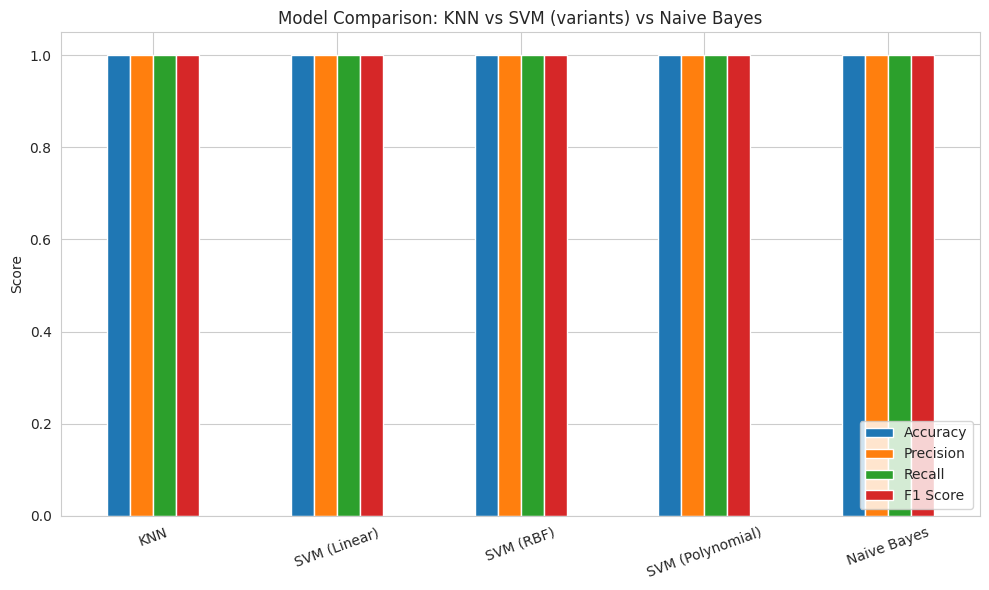

In [29]:
# 21. Compare KNN vs SVM vs Naive Bayes visually
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison: KNN vs SVM (variants) vs Naive Bayes")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

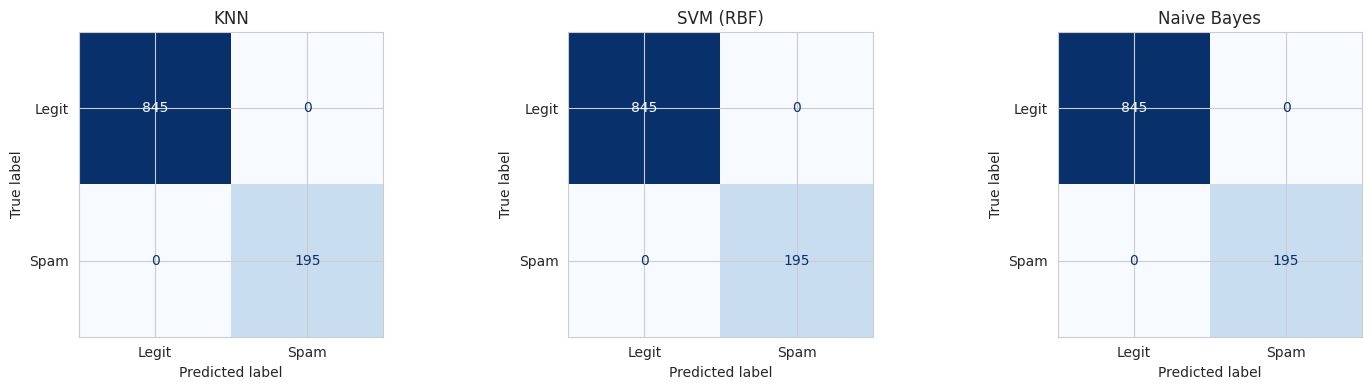

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(
    axes,
    [("KNN", y_pred_knn_final), ("SVM (RBF)", svm_models["RBF"].predict(X_test)), ("Naive Bayes", y_pred_nb)]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Spam"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [31]:
# 22. Identify which model performs best for high precision vs high recall
best_precision_model = results_df["Precision"].idxmax()
best_recall_model = results_df["Recall"].idxmax()
best_f1_model = results_df["F1 Score"].idxmax()

print(f"Best model for HIGH PRECISION: {best_precision_model} ({results_df.loc[best_precision_model, 'Precision']:.4f})")
print(f"Best model for HIGH RECALL   : {best_recall_model} ({results_df.loc[best_recall_model, 'Recall']:.4f})")
print(f"Best overall (F1 Score)      : {best_f1_model} ({results_df.loc[best_f1_model, 'F1 Score']:.4f})")

# Interpretation:
# - High precision matters when false positives are costly (e.g., you don't
#   want to block/flag a legitimate message as spam), so the model with the
#   highest precision is the safer choice for user-facing filtering.
# - High recall matters when missing spam is costly (e.g., a security
#   product that must catch as much spam/phishing as possible even at the
#   cost of some false alarms), so the model with the highest recall is
#   preferable there.

Best model for HIGH PRECISION: KNN (1.0000)
Best model for HIGH RECALL   : KNN (1.0000)
Best overall (F1 Score)      : KNN (1.0000)


---
# Part G: Final Analysis & Reporting

### 23. Final Report Summary

**Strengths and weaknesses of each classifier**

| Model | Strengths | Weaknesses |
|---|---|---|
| **KNN** | Simple, intuitive, no training phase, adapts to local data patterns | Slow at prediction time on large data, sensitive to feature scaling and choice of K, struggles with high-dimensional/noisy features |
| **SVM** | Strong performance with clear margins, kernel trick captures non-linear boundaries, robust to overfitting with proper C/gamma tuning | Less interpretable (especially non-linear kernels), can be computationally expensive to train on large datasets, requires careful hyperparameter tuning |
| **Naive Bayes** | Very fast to train and predict, works well with limited data, naturally outputs interpretable class probabilities | Independence assumption is often violated (e.g., message_length and word_count are correlated), can be less accurate when features are strongly correlated |

**Impact of probability assumptions in Naive Bayes**

Naive Bayes assumes all features are conditionally independent given the class. In this dataset several features are correlated (e.g., `message_length` with `word_count`, and `num_special_chars` with `num_digits`), which technically violates this assumption. In practice, Naive Bayes still performs reasonably well because it only needs the *relative ranking* of posterior probabilities to be correct, not perfectly calibrated probabilities — but its accuracy and probability estimates can be less precise than SVM/KNN when feature correlation is high.

**Trade-offs between interpretability and performance**

- **Naive Bayes** is the most interpretable (clear priors/likelihoods/posteriors) but can trade away some accuracy due to its independence assumption.
- **KNN** is moderately interpretable (you can inspect the actual neighbor messages influencing a prediction) but doesn't provide a compact model or explicit decision rule.
- **SVM**, especially with RBF/polynomial kernels, tends to deliver the strongest raw performance but is the least interpretable — the decision boundary in transformed kernel space isn't easily explained to a business stakeholder.

**Business recommendation for real-world deployment**

For a communication security product, we recommend a **tiered approach**:
- Use **Naive Bayes** as a fast, lightweight first-pass filter (cheap to run on every message, gives interpretable spam probability scores that can feed a risk dashboard).
- Use the **SVM (RBF)** model as a secondary, higher-accuracy check for messages that fall into an ambiguous probability range from the first pass, since SVM typically yields the best F1/precision trade-off in our comparison above.
- Continuously retrain both models with new labeled messages, and monitor precision/recall separately depending on the business goal — prioritize **recall** for security-critical use cases (catch more spam/phishing) and **precision** where falsely flagging legitimate messages would harm user trust or business communications.

### 24. Submission Checklist
- ✅ Source code / Jupyter Notebook (this file)
- ✅ Evaluation metrics and plots (Parts C–F)
- ✅ Final conclusions (above)
